# Multidimensional Data Visualisation — London Air Quality

Three direct visualisation methods:
1. **Parallel Coordinates** — all dimensions as parallel axes, each record as a polyline
2. *(next)*
3. *(next)*

Reusable: swap `CONFIG` to apply to a different dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from sklearn.cluster import KMeans

In [2]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
# Change these to reuse with another dataset.

CONFIG = {
    # Data
    'csv_path'       : 'data/2_unscaled/unscaled.csv',
    'date_col'       : 'date',

    # Which numeric dimensions to visualise
    'features'       : ['CO', 'O3', 'NO', 'NO2', 'PM10', 'PM2.5', 'wind_speed', 'temp'],

    # Target column — split into Low/Medium/High tertiles (used by SPLOM & Andrews)
    'target_col'     : 'PM2.5',
    'color_by'       : 'pm25_level',
    'color_map'      : {
        'Low'    : '#4e91d9',
        'Medium' : '#f4a261',
        'High'   : '#d62728',
    },

    # Clustering (used by Hierarchical Parallel Coordinates)
    'n_clusters'     : 3,
    'cluster_colors' : ['#2166ac', '#8B4513', '#b2182b'],
    'seed'           : 42,
}

In [3]:
# ── PIPELINE FUNCTIONS ────────────────────────────────────────────────────────

def load_data(csv_path, date_col):
    return pd.read_csv(csv_path, parse_dates=[date_col])


def daily_means(df, date_col, features):
    """Aggregate hourly readings to daily means, drop days with any NaN feature."""
    return (
        df.groupby(df[date_col].dt.date)[features]
        .mean()
        .dropna()
        .reset_index(drop=True)
    )


def add_pm25_level(df, target_col):
    """Bucket target_col into Low / Medium / High tertiles."""
    return df.assign(
        pm25_level=pd.qcut(df[target_col], q=3, labels=['Low', 'Medium', 'High'])
    )


def add_clusters(df, features, n_clusters, seed, sort_by='PM2.5'):
    """KMeans clustering on normalised features.
    Clusters are sorted by mean `sort_by` so colours stay consistent with PM2.5 levels."""
    normed = minmax_normalize(df, features)
    km = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
    raw_labels = km.fit_predict(normed[features])

    tmp = pd.DataFrame({'cluster': raw_labels, sort_by: df[sort_by].values})
    sorted_ids = tmp.groupby('cluster')[sort_by].mean().sort_values().index.tolist()
    rank_map = {old_id: new_id for new_id, old_id in enumerate(sorted_ids)}

    labels = np.array([rank_map[l] for l in raw_labels])
    centers_reordered = km.cluster_centers_[sorted_ids]

    distances = np.linalg.norm(
        normed[features].values - centers_reordered[labels], axis=1
    )
    return df.assign(cluster=labels, cluster_dist=distances), centers_reordered


def prepare(df, *, features, target_col, date_col, **_):
    return (
        df
        .pipe(daily_means, date_col=date_col, features=features)
        .pipe(add_pm25_level, target_col=target_col)
        .reset_index(drop=True)
    )


def minmax_normalize(df, features):
    """Min-max scale each feature to [0, 1] independently (for plotting only)."""
    normed = df[features].copy()
    for f in features:
        lo, hi = df[f].min(), df[f].max()
        normed[f] = (df[f] - lo) / (hi - lo)
    return normed

## Method 1 — Hierarchical Parallel Coordinates

Parallel Coordinates variantas dideliems duomenų rinkiniams:
1. Duomenys grupuojami į klasterius (K-Means)
2. Kiekvienas klasteris — sava spalva
3. **Klasterio centras** — stora, visiškai nepermatoma linija
4. **Klasterio nariai** — plonos linijos, permatomumas pagal atstumą nuo centro (arčiau centro = ryškesnis)

Taip išvengiama linijų susiliejimo problemos ir matoma duomenų struktūra.

In [4]:
CLUSTER_LABELS = ['Low PM2.5', 'Medium PM2.5', 'High PM2.5']

def plot_hierarchical_parallel_coordinates(df, centers, *, features, cluster_colors,
                                           cluster_labels=CLUSTER_LABELS,
                                           title='Hierarchical Parallel Coordinates',
                                           alpha_min=0.03, alpha_max=0.3, linewidth=0.6,
                                           center_linewidth=4.0):
    normed = minmax_normalize(df, features)
    x = np.arange(len(features))

    fig, ax = plt.subplots(figsize=(14, 6))

    for cluster_id, color in enumerate(cluster_colors):
        mask = df['cluster'] == cluster_id
        rows = normed[mask][features].values
        dists = df.loc[mask, 'cluster_dist'].values

        if len(rows) == 0:
            continue

        d_max = dists.max() if dists.max() > 0 else 1
        d_norm = dists / d_max

        rgb = mcolors.to_rgb(color)
        line_colors = [(*rgb, alpha_max * (1 - d) + alpha_min * d) for d in d_norm]

        segs = [np.column_stack([x, row]) for row in rows]
        lc = LineCollection(segs, colors=line_colors, linewidths=linewidth, zorder=2)
        ax.add_collection(lc)

    for cluster_id, color in enumerate(cluster_colors):
        center = centers[cluster_id]
        n = int((df['cluster'] == cluster_id).sum())
        label = cluster_labels[cluster_id] if cluster_id < len(cluster_labels) else f'Cluster {cluster_id + 1}'
        ax.plot(x, center, color='black', linewidth=center_linewidth + 1.5, zorder=5, solid_capstyle='round')
        ax.plot(x, center, color=color, linewidth=center_linewidth, zorder=6, solid_capstyle='round',
                label=f'{label}  (n={n})')

    ax.set_xlim(-0.5, len(features) - 0.5)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(features, fontsize=11)
    ax.set_ylabel('Normalised value  [0 – 1]', fontsize=10)
    ax.set_title(title, fontsize=13, pad=10)
    ax.grid(axis='x', color='#cccccc', linewidth=0.8)
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

    for xi in x:
        ax.axvline(xi, color='#555555', linewidth=1.2, zorder=3)

    ax.legend(loc='upper right', framealpha=0.9, fontsize=9)
    plt.tight_layout()
    return fig

Dienų po agregacijos: 4131
PM2.5 tertilių ribos:
              min    max
pm25_level              
Low          1.33   9.95
Medium       9.95  15.47
High        15.48  95.77


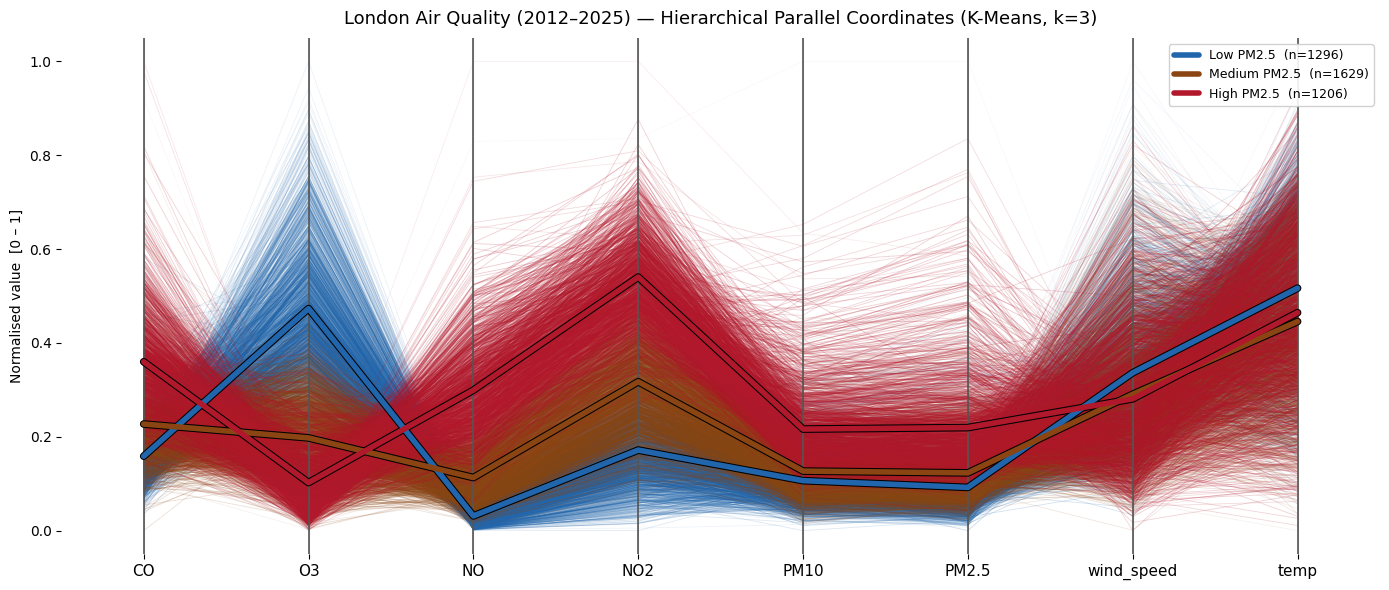

In [5]:
# ── RUN ───────────────────────────────────────────────────────────────────────
# df_plot yra pagrindinis objektas — reused visų trijų metodų

df_raw  = load_data(CONFIG['csv_path'], CONFIG['date_col'])
df_plot = prepare(df_raw, **CONFIG)

print(f"Dienų po agregacijos: {len(df_plot)}")
print(f"PM2.5 tertilių ribos:\n{df_plot.groupby('pm25_level')['PM2.5'].agg(['min','max']).round(2)}")

df_clustered, centers = add_clusters(
    df_plot, CONFIG['features'], CONFIG['n_clusters'], CONFIG['seed']
)

fig1 = plot_hierarchical_parallel_coordinates(
    df_clustered, centers,
    features        = CONFIG['features'],
    cluster_colors  = CONFIG['cluster_colors'],
    title           = 'London Air Quality (2012–2025) — Hierarchical Parallel Coordinates (K-Means, k=3)',
)
plt.show()

### Observations — Hierarchical Parallel Coordinates

*(fill in after seeing the plot)*

- Kiekviena stora linija = klasterio centras (tipinis tos grupės dienos profilis).
- Plonos to paties klasterio linijos rodo kaip nariai nukrypsta nuo centro — kuo permatomesnė, tuo toliau nuo centro.
- Jei klasterių centrai stipriai skiriasi ties PM10 ir PM2.5 ašimis — tai patvirtina šių features svarbą.
- Klasteriai gali natūraliai atitikti sezonus arba teršalų lygio grupes — tai galima patikrinti papildomai.

## Method 2 — Scatter Plot Matrix (SPLOM)

N×N tinklelis scatter plot'ų — kiekvienas langelis rodo **du features vienas prieš kitą**.  
Diagonal'ėje — kiekvieno feature histograma pagal PM2.5 grupę.  
Taškas = viena diena. Spalva = PM2.5 lygis (tie patys tertiliai).

**Kaip skaityti:** langelyje, kuriame Low/Medium/High taškai labiausiai atsiskiria — tie du features kartu geriausiai nuspėja PM2.5.

In [6]:
from pandas.plotting import scatter_matrix

def plot_scatter_matrix(df, *, features, color_by, color_map, title='Scatter Plot Matrix', alpha=0.25, size=6):
    """
    Parameters
    ----------
    df        : DataFrame with `features` columns + `color_by` column (reuses prepare() output)
    features  : list of column names — same as parallel coordinates
    color_by  : categorical column for colour grouping
    color_map : dict {category: hex_color} — same as parallel coordinates
    """
    colors = df[color_by].map(color_map).values

    fig, axes = plt.subplots(len(features), len(features),
                             figsize=(16, 16), constrained_layout=True)

    scatter_matrix(
        df[features],
        ax=axes,
        c=colors,
        alpha=alpha,
        marker='.',
        s=size,
        diagonal='hist',
        hist_kwds={'bins': 30, 'edgecolor': 'none'},
    )

    # Diagonal histograms — redraw per group so colours stack correctly
    for i, feat in enumerate(features):
        axes[i, i].cla()
        for cat, color in color_map.items():
            mask = df[color_by] == cat
            axes[i, i].hist(df.loc[mask, feat], bins=30, color=color,
                            alpha=0.5, edgecolor='none', density=True)
        axes[i, i].set_ylabel('')

    # Axis labels only on edges
    for i, feat in enumerate(features):
        axes[-1, i].set_xlabel(feat, fontsize=8, rotation=20, ha='right')
        axes[i, 0].set_ylabel(feat, fontsize=8, rotation=0, ha='right', labelpad=40)

    # Legend
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                           markersize=7, label=k)
               for k, c in color_map.items()]
    fig.legend(handles=handles, title=color_by.replace('_', ' ').capitalize(),
               loc='upper right', fontsize=9, framealpha=0.9)

    fig.suptitle(title, fontsize=13, y=1.01)
    return fig

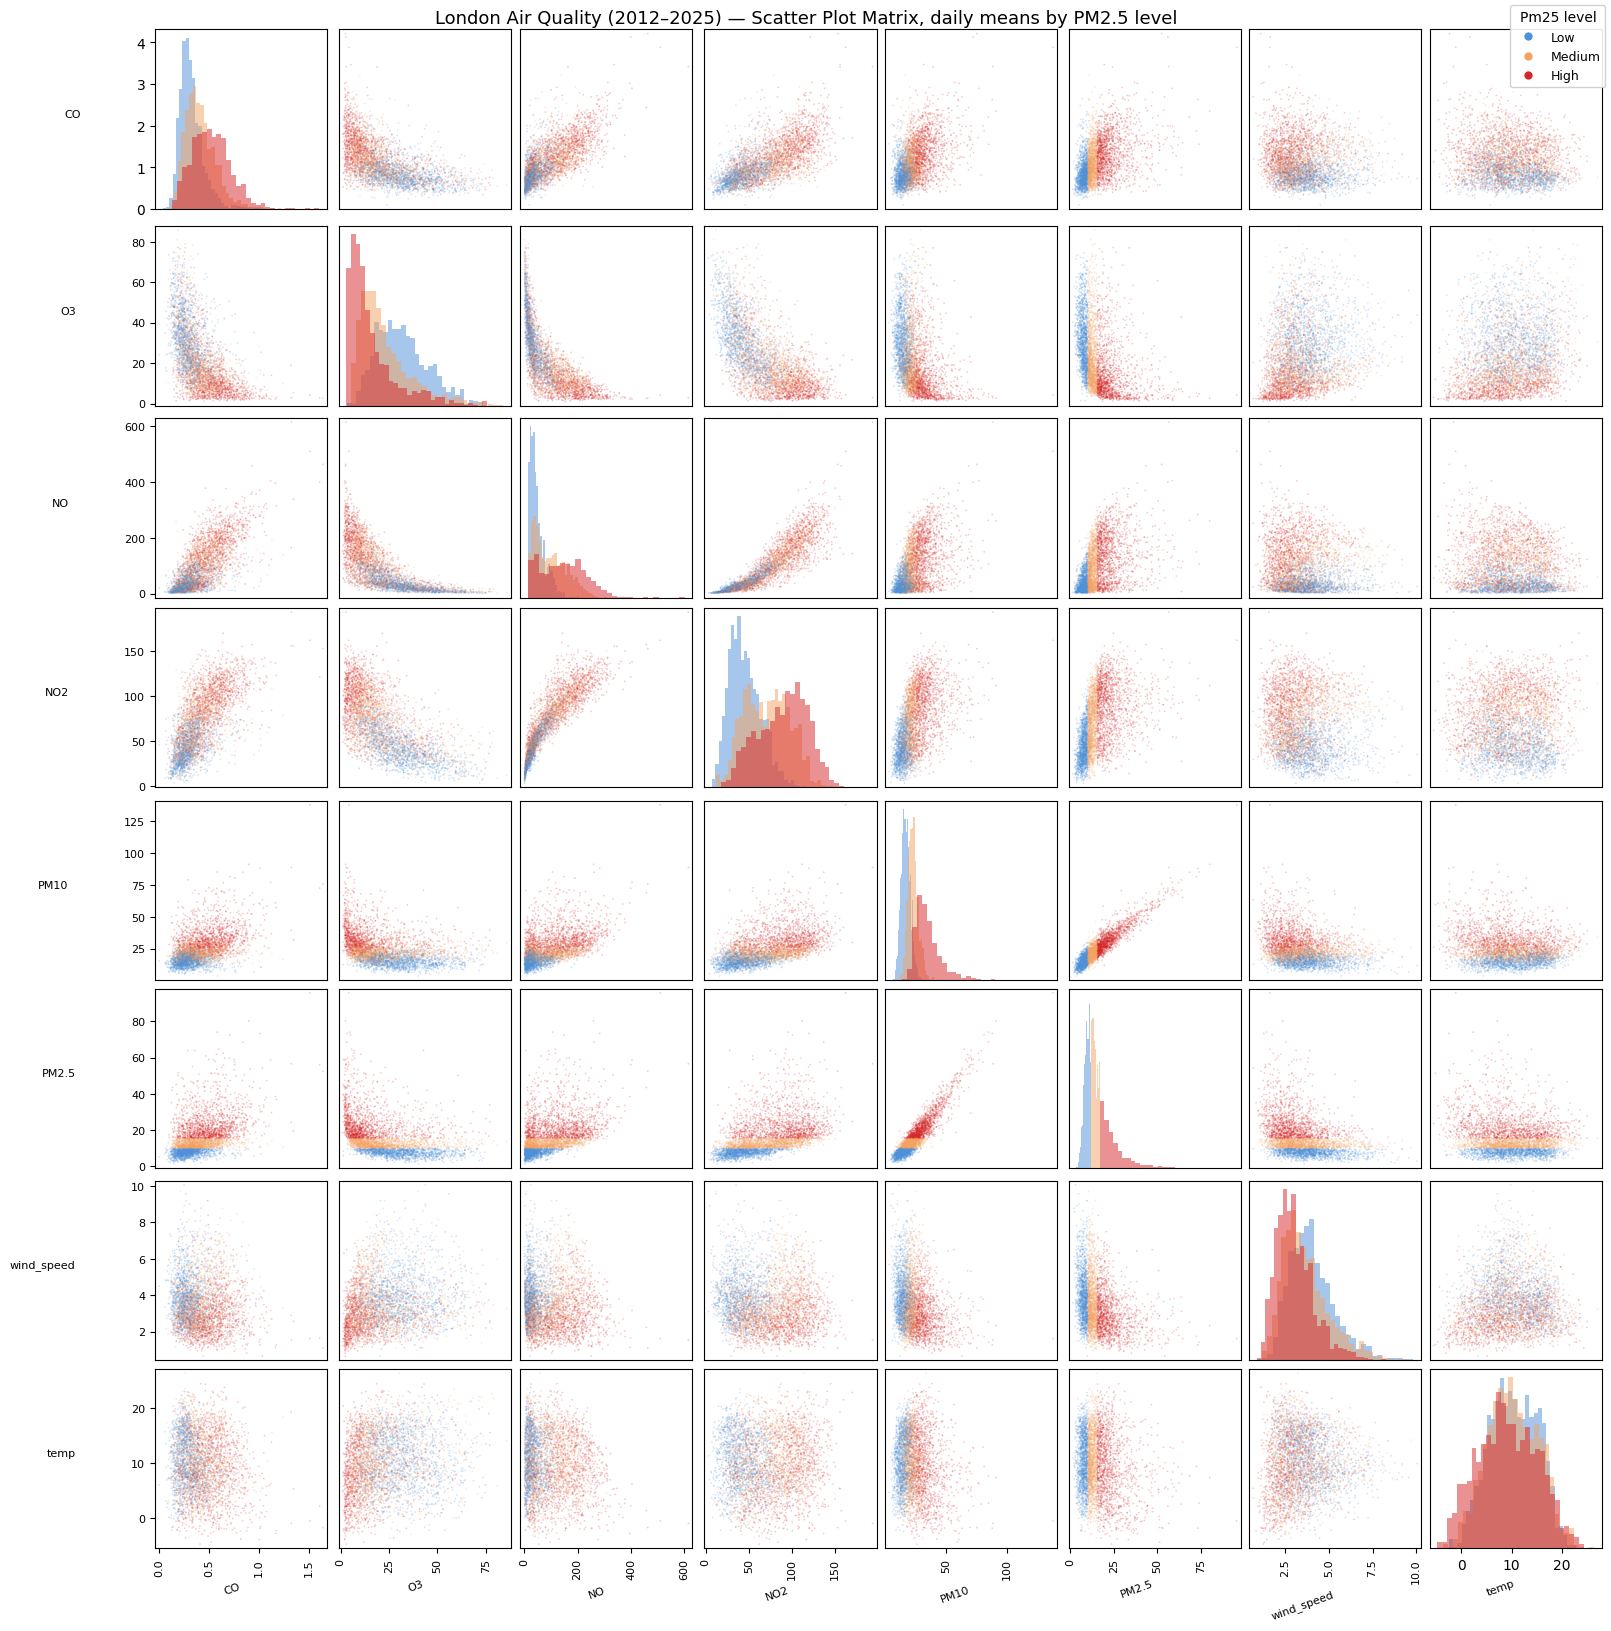

In [7]:
# ── RUN — reuses df_plot from Method 1 ───────────────────────────────────────

fig2 = plot_scatter_matrix(
    df_plot,
    features  = CONFIG['features'],
    color_by  = CONFIG['color_by'],
    color_map = CONFIG['color_map'],
    title     = 'London Air Quality (2012–2025) — Scatter Plot Matrix, daily means by PM2.5 level',
)
plt.show()

### Observations — Scatter Plot Matrix

*(fill in after seeing the plot)*

- **PM10 × PM2.5** langelis — taškai išsirikiavę beveik tiesiškai, spalvos aiškiai atsiskiria: mėlyna apačioje kairėje, raudona viršuje dešinėje. Stipriausia tiesinė priklausomybė (r = 0.87).
- **NO × NO2** langelis — labai stipri koreliacija, taškai siaurai išsidėstę palei tiesę.
- **O3 × NO / NO2** langeliai — atvirkštinė priklausomybė: kai NO aukštas, O3 žemas (fotocheminė reakcija).
- **wind_speed** langeliai — silpnesni ryšiai, taškai labiau išsklaidyti.
- **Diagonal'ėje** — High PM2.5 (raudona) histogramos pastumtos į dešinę PM10 ir NO ašyse, į kairę O3 ašyje.

## Method 3 — Andrews Curves

Kiekvienas įrašas (diena) paverčiamas trigonometrine kreive:  
`f(t) = x₁/√2 + x₂sin(t) + x₃cos(t) + x₄sin(2t) + x₅cos(2t) + ...`  
kur x₁..xₙ — to įrašo feature reikšmės (min-max normalizuotos).

Spalva = PM2.5 lygis (tie patys tertiliai).  
**Kaip skaityti:** jei tos pačios spalvos kreivės susikaupia į ryšulį — features kartu gerai apibūdina PM2.5 grupę. Kuo aiškiau grupės atsiskiria, tuo informatyvesnis feature rinkinys.

In [8]:
def plot_andrews_curves(df, *, features, color_by, color_map, title='Andrews Curves',
                        alpha=0.05, linewidth=0.6, n_points=200, sample_n=800, seed=42):
    t = np.linspace(-np.pi, np.pi, n_points)

    def basis(n_features):
        B = np.zeros((len(t), n_features))
        B[:, 0] = 1 / np.sqrt(2)
        for k in range(1, n_features):
            freq = (k + 1) // 2
            B[:, k] = np.sin(freq * t) if k % 2 == 1 else np.cos(freq * t)
        return B

    normed = minmax_normalize(df, features)
    X = normed[features].values
    B = basis(len(features))

    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=min(sample_n, len(X)), replace=False)

    all_curves = X[idx] @ B.T      # (sample_n, n_points) — for y limits
    y_min, y_max = all_curves.min(), all_curves.max()
    margin = (y_max - y_min) * 0.05

    fig, ax = plt.subplots(figsize=(14, 6))

    for cat, color in color_map.items():
        mask = (df[color_by] == cat).values
        cat_idx = idx[mask[idx]]
        curves = X[cat_idx] @ B.T

        segs = [np.column_stack([t, curve]) for curve in curves]
        lc = LineCollection(segs, colors=color, alpha=alpha, linewidths=linewidth)
        ax.add_collection(lc)

    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(y_min - margin, y_max + margin)

    ax.set_xlabel('t', fontsize=10)
    ax.set_ylabel('f(t)', fontsize=10)
    ax.set_title(title, fontsize=13, pad=10)
    ax.axhline(0, color='#aaaaaa', linewidth=0.8, linestyle='--')
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

    handles = [plt.Line2D([0], [0], color=c, linewidth=2.5, label=k)
               for k, c in color_map.items()]
    ax.legend(handles=handles, title=color_by.replace('_', ' ').capitalize(),
              loc='upper right', framealpha=0.9, fontsize=9)

    plt.tight_layout()
    return fig

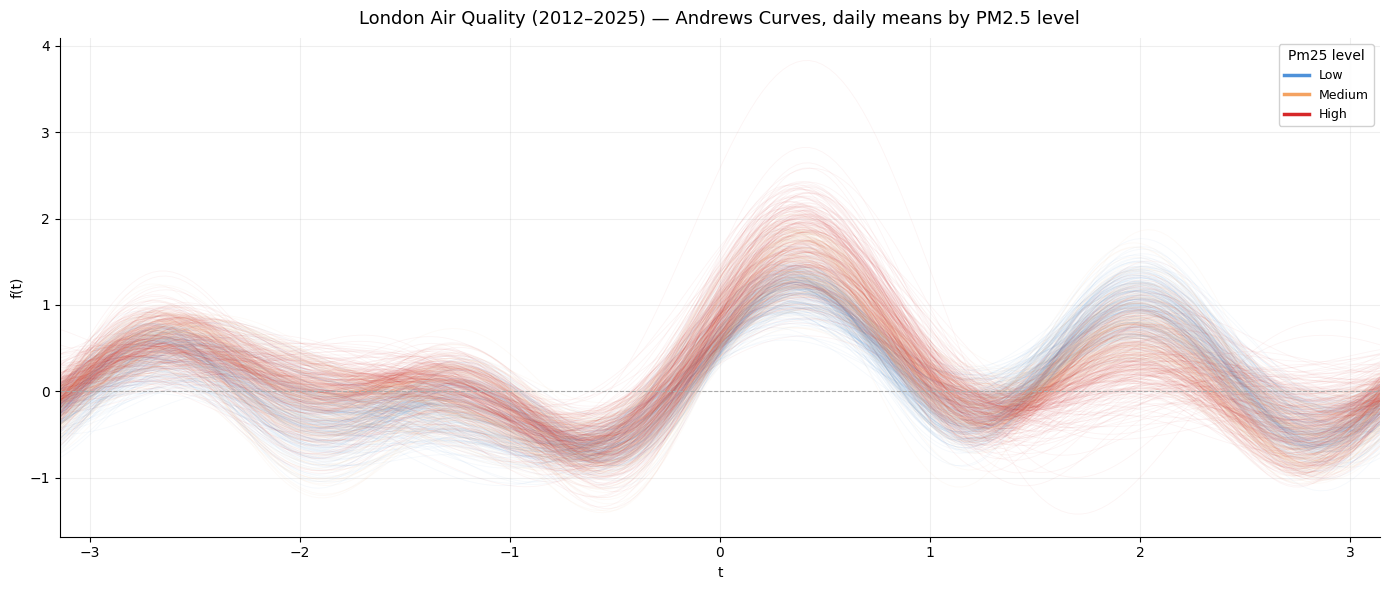

In [9]:
# ── RUN — reuses df_plot from Method 1 ───────────────────────────────────────

fig3 = plot_andrews_curves(
    df_plot,
    features  = CONFIG['features'],
    color_by  = CONFIG['color_by'],
    color_map = CONFIG['color_map'],
    title     = 'London Air Quality (2012–2025) — Andrews Curves, daily means by PM2.5 level',
)
plt.show()

### Observations — Andrews Curves

*(fill in after seeing the plot)*

- Jei High PM2.5 (raudona) kreivės susikaupia **aukščiau** o Low (mėlyna) **žemiau** — features kartu gerai atskiria PM2.5 lygius.
- Kreivių forma priklauso nuo **feature eiliškumo** — pirmieji features (CO, O3) lemia bendrą kreivės lygį, vėlesni (wind_speed, temp) — bangavimą.
- Palyginus su Parallel Coordinates: ten matėme atskirų dimensijų indėlį, čia matome **kombinuotą visų features profilį** kaip vieną objektą.